In [1]:
import pandas as pd
import sys
import os
import numpy as np
import seaborn as sns
import subprocess
import time
import pysam
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as colors
from matplotlib.patches import Rectangle
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator

In [2]:
working_dir = "./exemplar_figures/"

## Figure 1A

In [ ]:
ident_path = "./exemplar_data/whole_genome_IVT_GM12878_chr22_10000000_15000000_read_stats.txt"
total = 0
with open(ident_path, 'r') as infile:
    for line in tqdm(infile):
        if line.split('\t')[1] == "Read_Length":
            continue
        total += 1

read_length = [0] * total
aligned_length = [0] * total
identity = [0] * total

with open(ident_path, 'r') as infile:
    for i, line in enumerate(infile):
        if i == 0:
            continue
        read_length[i-1] = int(line.split('\t')[1])
        aligned_length[i-1] = int(line.split('\t')[3])
        identity[i-1] = float(line.split('\t')[4])

In [ ]:
fig, ax = plt.subplots(1, dpi=600)
fig.set_figwidth(16)
fig.set_figheight(12)
density = ax.hist2d(x = read_length, 
                    y = identity, 
                    cmap='coolwarm', 
                    norm=colors.LogNorm(), 
                    range=[[0,3000],[0, 1]],
                    bins=[100, 100]
                   )
fig.colorbar(density[3], label='Number of points per square')
ax.grid(False)
plt.xlabel('R10 Methylation Proportion')
plt.ylabel('R9 Methylation Proportion')

fig.get_figure().savefig(os.path.join(working_dir, "Heatmap.pdf"))

In [ ]:
fig, ax = plt.subplots(1, dpi=600)
fig.set_figwidth(12)
fig.set_figheight(4)
sns.kdeplot(read_length, clip=[0, 3000], linewidth=0.25, fill=True, bw_adjust=0.5)
fig.get_figure().savefig(os.path.join(working_dir, "read_length_kde.pdf"))

In [ ]:
fig, ax = plt.subplots(1, dpi=600)
fig.set_figwidth(12)
fig.set_figheight(4)
sns.kdeplot(identity, clip=[0, 1], linewidth=0.25, fill=True, bw_adjust=2.5)
fig.get_figure().savefig(os.path.join(working_dir,"identity.pdf"))

## Figure 1B

25854it [00:00, 1494892.96it/s]

0.0033632286995515697 median insertion proportion
0.004545454545454545 median deletion proportion
0.009345794392523364 median mismatch proportion


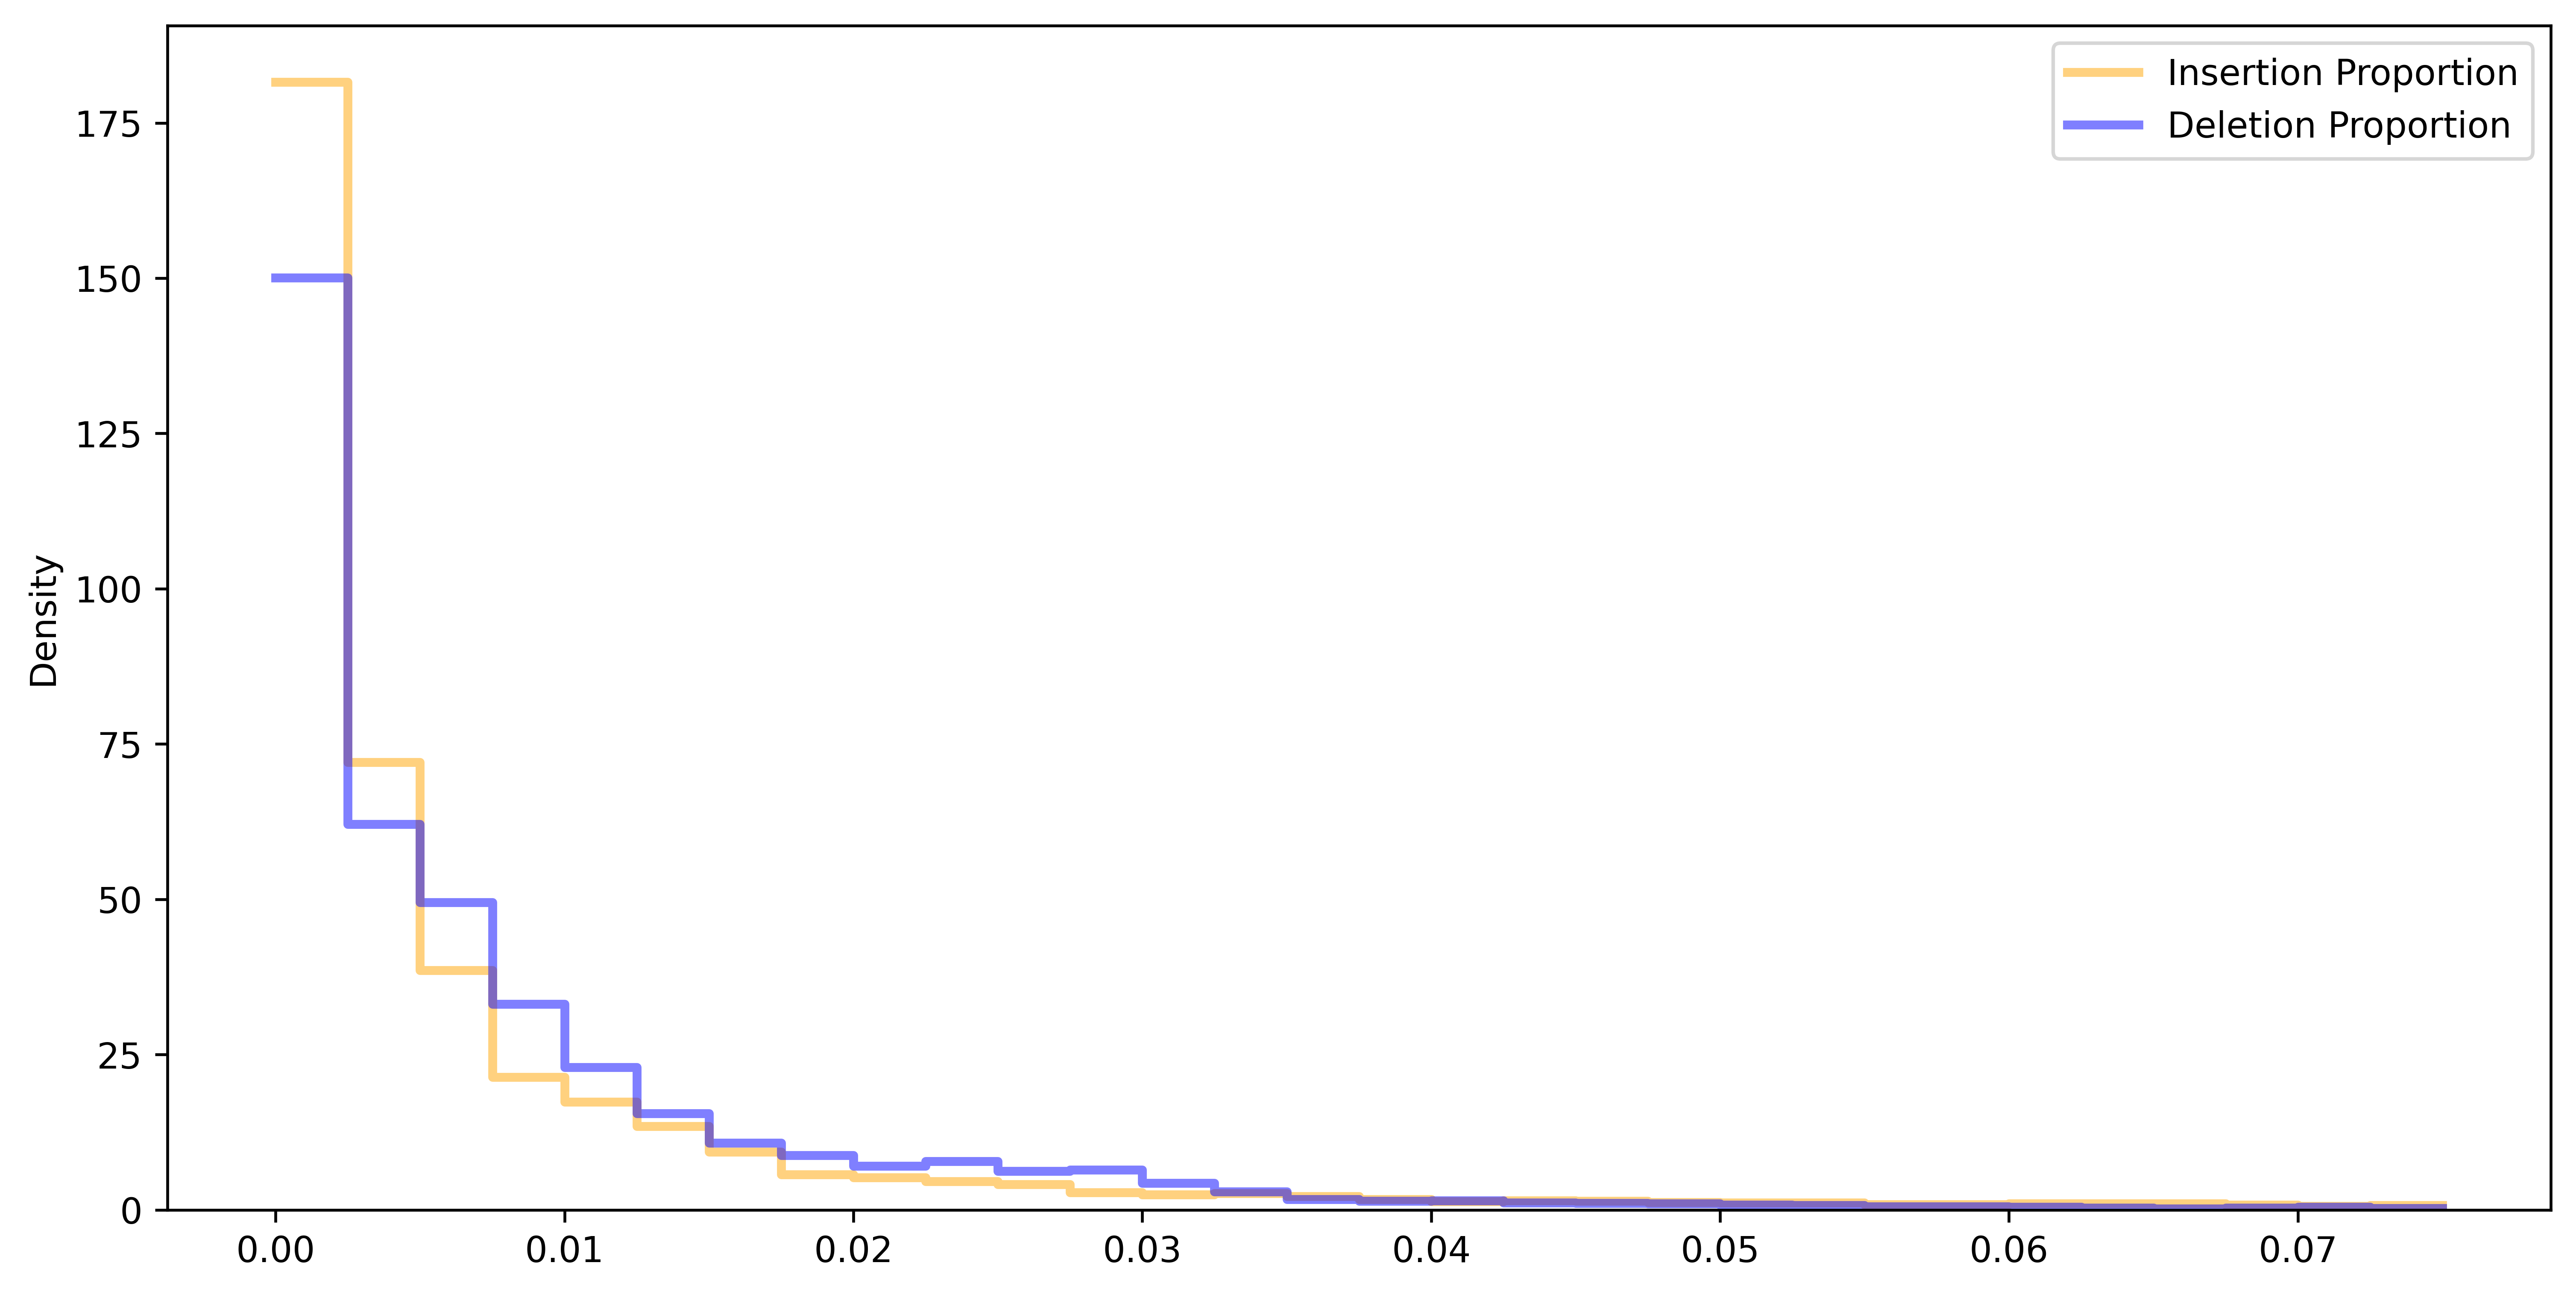

In [3]:
ident_path = "./exemplar_data/whole_genome_IVT_GM12878_chr22_10000000_15000000_read_stats.txt"
total = 0

with open(ident_path, 'r') as infile:
    for line in tqdm(infile):
        if line.split('\t')[1] == "Read_Length":
            continue
        total += 1

aligned_length = [0] * total
insertions = [0] * total
deletions = [0] * total
mismatches = [0] * total

with open(ident_path, 'r') as infile:
    for i, line in enumerate(infile):
        if i == 0:
            continue
        aligned_length[i-1] = int(line.split('\t')[3])
        insertions[i-1] = int(line.split('\t')[7])
        deletions[i-1] = int(line.split('\t')[8])
        mismatches[i-1] = int(line.split('\t')[6])

insertion_proportion = [x/y for x,y in zip(insertions, aligned_length)]
deletion_proportion = [x/y for x,y in zip(deletions, aligned_length)]
mismatch_proportion = [x/y for x,y in zip(mismatches, aligned_length)]
print(f"{np.median(insertion_proportion)} median insertion proportion")
print(f"{np.median(deletion_proportion)} median deletion proportion")
print(f"{np.median(mismatch_proportion)} median mismatch proportion")

fig, ax = plt.subplots(1, dpi=600)
fig.set_figwidth(12)
fig.set_figheight(6)
sns.histplot(insertion_proportion, binrange=[0, 0.075], alpha = 0.5, linewidth=2.5, binwidth=0.0025, color = 'orange', fill=False, stat = "density", element="step", label="Insertion Proportion")
sns.histplot(deletion_proportion, binrange=[0, 0.075], alpha = 0.5, linewidth=2.5, binwidth=0.0025, color = 'blue', fill=False, stat = "density", element="step", label="Deletion Proportion")
ax.legend()

#fig.get_figure().savefig(os.path.join(working_dir, "indel_proportions.pdf"))

## Figure 1C

In [6]:
def mer_counts_reference(ref_path, mer_count):    
    assert mer_count % 2 == 1
    flank = int((mer_count - 1)/2)
    count_dict = defaultdict(int)
    with pysam.FastxFile(ref_path) as fh:
        for entry in tqdm(fh):
            for i in range(4, len(entry.sequence)-4):
                count_dict[entry.sequence[i-flank:i+flank+1]] += 1
    return count_dict

def filter_N(in_dict):
    base_set = {'A', 'T', 'C', 'G'}
    out_dict = {}
    for key in in_dict:
        if sum([x in base_set for x in key]) != 9:
            continue
        else:
            out_dict[key] = in_dict[key]
    return out_dict

def kmer_density(in_dict):
    out_dict = {}
    total_9mers = sum(in_dict.values())
    for key, value in in_dict.items():
        out_dict[key] = value / total_9mers
    return out_dict

In [4]:
#This will download the reference file used for this project, if you have it locally just provide the path
subprocess.run(["wget",
                "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/000/001/405/GCA_000001405.15_GRCh38/seqs_for_alignment_pipelines.ucsc_ids/GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.gz"],
              stdout=subprocess.DEVNULL,
              stderr=subprocess.DEVNULL)
subprocess.run(["gunzip",
                "GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.gz"])

gunzip: GCA_000001405.15_GRCh38_no_alt_analysis_set.fna already exists -- skipping


CompletedProcess(args=['gunzip', 'GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.gz'], returncode=1)

In [11]:
ref_path = "GCA_000001405.15_GRCh38_no_alt_analysis_set.fna" #Replace with local installation of reference 
d = mer_counts_reference(ref_path, 9)
d = filter_N(d)
d = kmer_density(d)   


195it [14:38,  4.51s/it]


ValueError: Length mismatch: Expected axis has 1 elements, new values have 2 elements

In [17]:
ref_kmer_df = pd.DataFrame.from_dict(d, orient="index")
ref_kmer_df.reset_index(inplace=True)
ref_kmer_df.columns = ["kmer", "density"]

In [18]:
observed_kmer_df = pd.read_csv(os.path.join("../error_tables/GM12878_genomic_IVT_refmatch_9mer_all_threshold.dorado_1.0.tsv.gz"), sep="\t", usecols=[0,1,32])
observed_kmer_df.columns = ["kmer", "mod", "count"]
observed_kmer_df = observed_kmer_df[((observed_kmer_df["mod"] != "17596") & 
                                     (observed_kmer_df["mod"] != "19227") &
                                     (observed_kmer_df["mod"] != "19228") &
                                     (observed_kmer_df["mod"] != "69426"))]
observed_kmer_df.sort_values(by="count", ascending = True).head()

,kmer,mod,count
85903,CGATACGCG,a,218
5828,CGATCGACG,m,232
512279,CGTCGATCG,19229,239
20296,TATCGCGCG,19229,245
176560,TCGCGCGTA,19229,248


In [19]:
observed_density = [0] * observed_kmer_df.shape[0]

In [20]:
total_observed = sum(observed_kmer_df["count"])

In [21]:
counts = observed_kmer_df["count"].to_list()
for i in range(len(observed_density)):
    observed_density[i] = counts[i]/total_observed

In [22]:
observed_kmer_df["density"] = observed_density

In [23]:
merged_df = observed_kmer_df.merge(ref_kmer_df, how="outer", on="kmer", suffixes=['_observed', '_reference'])

In [24]:
merged_df.sort_values(by="density_reference", inplace=True, ascending=False)

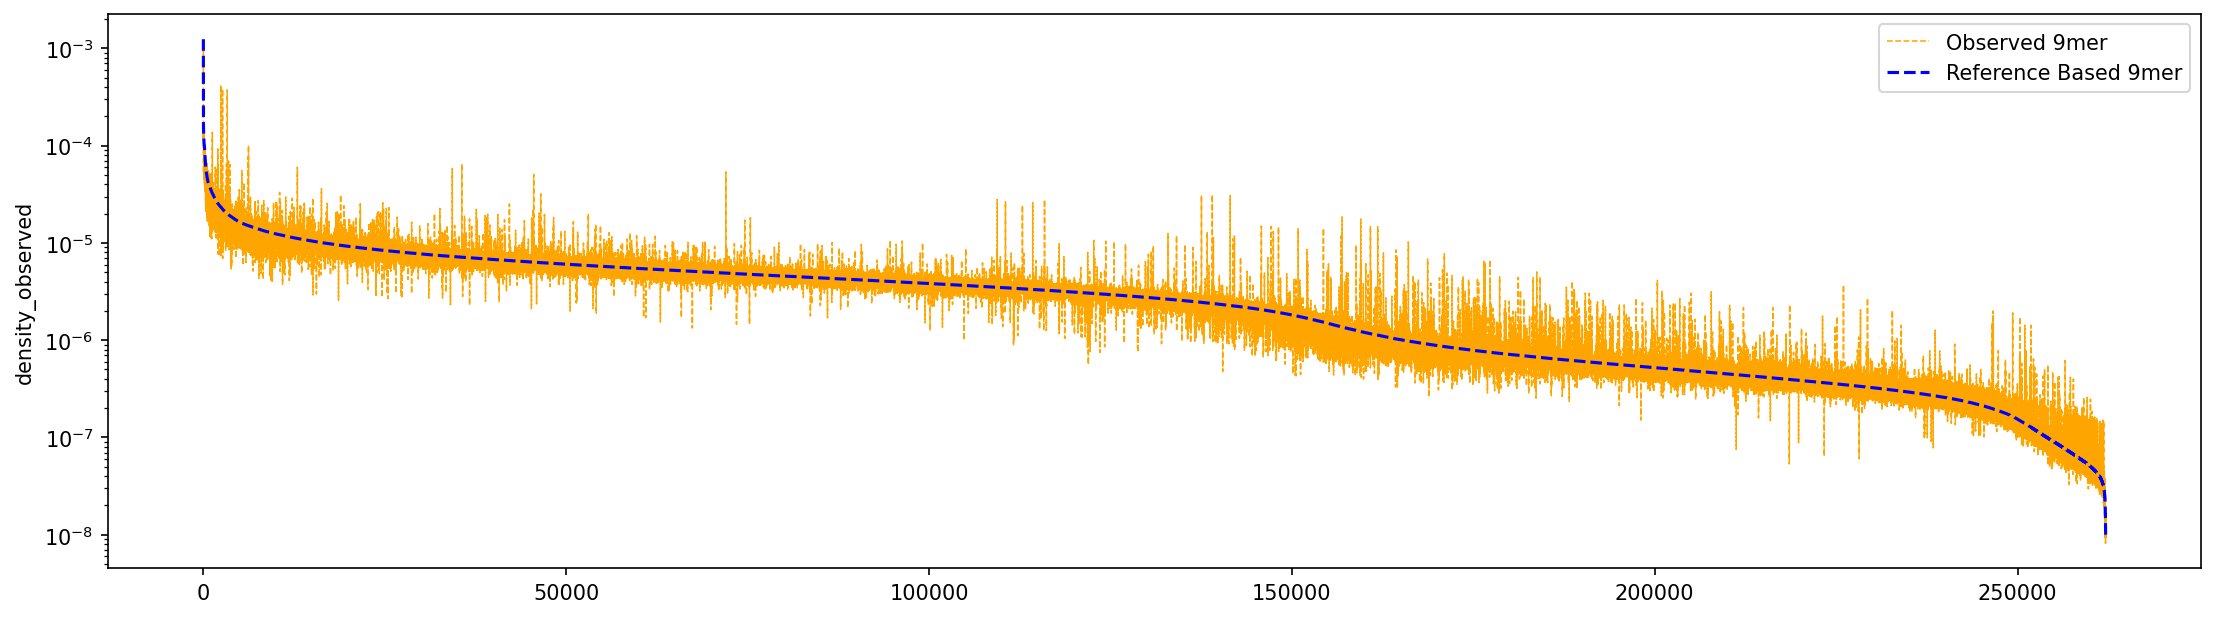

In [27]:
fig, ax = plt.subplots(1, dpi=150)
fig.set_figwidth(18)
sns.lineplot(x = [i for i in range(merged_df.shape[0])], y = merged_df["density_observed"], linewidth = 0.75, label = "Observed 9mer", linestyle = '--', color='orange')
sns.lineplot(x = [i for i in range(merged_df.shape[0])], y = merged_df["density_reference"], linewidth = 1.5, label = "Reference Based 9mer", linestyle = '--', color='b')
ax.set_yscale('log')
fig.get_figure().savefig(os.path.join(working_dir, "9mer_coverage.png"))